# Data Science Project - Individual Planning Report
**Course:** DSCI 100 

**Student:** Damian Olender

**Group Number:** 009-27

**Student ID:** 49601586

## (1) Data Description

The `players.csv` dataset contains information on 196 unique Minecraft players from a UBC research server. Each row represents one player and includes seven variables:

- **experience**: categorical, describes player skill level (Beginner, Amateur, Regular, Pro, Veteran).  
- **subscribe**: logical, indicates if the player subscribed to the newsletter.  
- **hashedEmail**: unique player identifier.  
- **played_hours**: numeric, total recorded hours of play.  
- **name**: text field, player name.  
- **gender**: categorical, includes Male, Female, Non-binary, Agender, Two-Spirited, Prefer not to say, and Other.  
- **Age**: numeric, player age in years (two missing values).

There are 196 observations and 7 variables. The mean `Age` is 21.14 years, and mean `played_hours` is 5.85 hours. About 73% of players subscribed to the newsletter.  
Potential data issues include missing age values, unbalanced classes for `subscribe`, and rare gender categories.  
These data appear tidy since each column is a variable, each row a player, and each cell contains one value.  
Since this project focuses on predicting newsletter subscription, only `players.csv` is required for this stage.

## (2) Questions

**Broad Question:**  
*What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?*

**Specific Question:**  
*How do player experience, age, and total hours played relate to newsletter subscription status in the `players.csv` dataset?*

These variables include both demographic and engagement features that may influence newsletter subscription.  
Minimal wrangling is required: factor encoding for categorical variables and mean changes for missing `Age` values will prepare the dataset for modeling in the next project stage.

# **(3) Exploratory Data Analysis and Visualization**

## **Step 1: Load and preview data**

In [9]:
# Load required packages
library(tidyverse)

# Load the datasets
players <- read_csv("players.csv")

# Preview
head(players)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


## **Step 2: Minimal wrangling (tidy format)**

In [10]:
# Basic tidying
players_tidy <- players |>
  rename(player_id = hashedEmail, subscribed = subscribe, total_hours = played_hours) |>
  mutate(subscribed = as.factor(subscribed), gender = as.factor(gender))

head(players_tidy)

experience,subscribed,player_id,total_hours,name,gender,Age
<chr>,<fct>,<chr>,<dbl>,<chr>,<fct>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


## **Step 3: Compute mean for each quantitative variable in `players.csv`**

In [11]:
players_means <- players_tidy |>
  summarise(mean_total_hours = mean(total_hours, na.rm = TRUE), mean_age = mean(Age, na.rm = TRUE))

players_means

mean_total_hours,mean_age
<dbl>,<dbl>
5.845918,21.13918


## **Step 4: Exploratory Visualizations (2 plots)**

Plot 1: Relationship between age and total hours by subscription status

Plot 2: Subscription rate by player experience

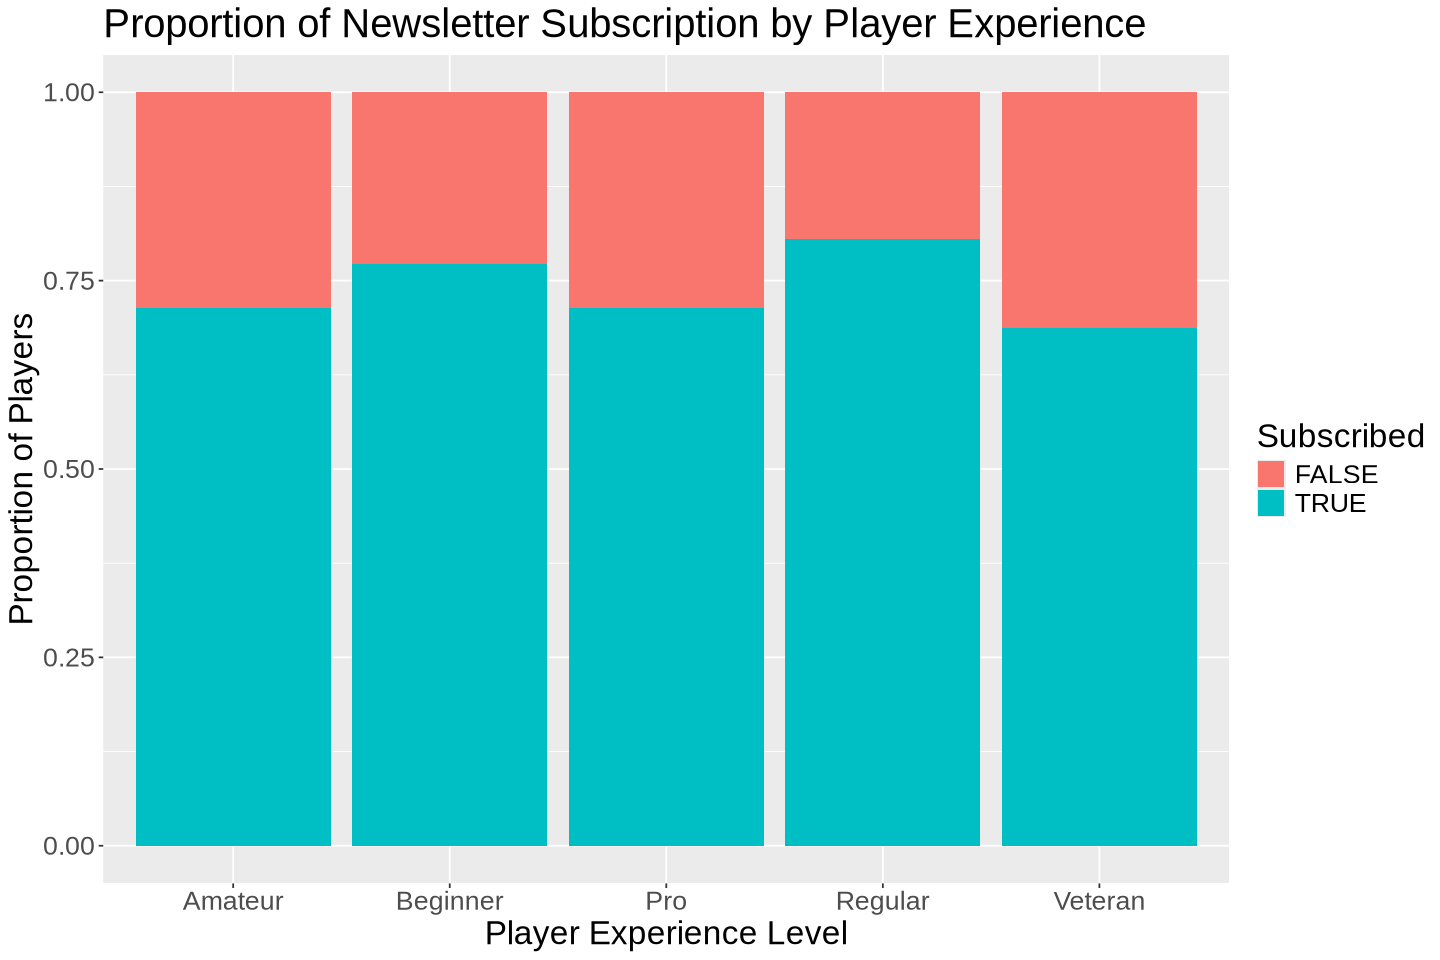

In [17]:
# Plot 1: Subscription rate by player experience
options(repr.plot.height = 8, repr.plot.width = 12)
players_tidy |>
  ggplot(aes(x = experience, fill = subscribed)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion of Newsletter Subscription by Player Experience", x = "Player Experience Level", y = "Proportion of Players",
  fill = "Subscribed") +
theme(text = element_text(size = 20)) 

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


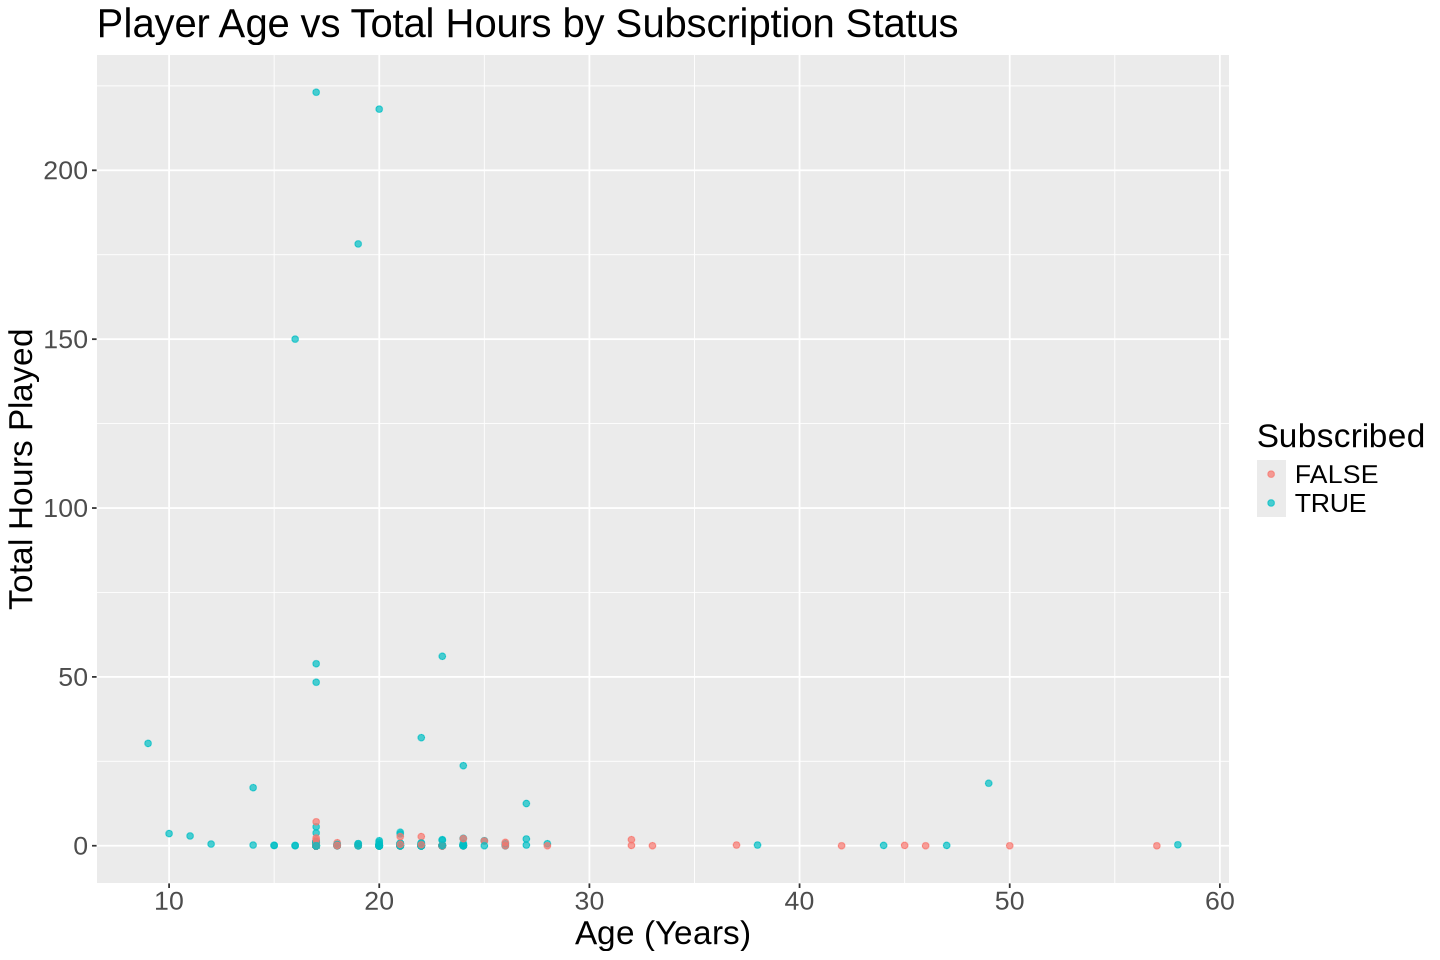

In [21]:
#Plot 2: Relationship between age and total hours by subscription status

options(repr.plot.height = 8, repr.plot.width = 12)
players_tidy |>
  ggplot(aes(x = Age, y = total_hours, color = subscribed)) +
  geom_point(alpha = 0.7) +
  labs(title = "Player Age vs Total Hours by Subscription Status", x = "Age (Years)", y = "Total Hours Played", color = "Subscribed") +
theme(text = element_text(size = 20)) 

## **Step 5: Insights from the Visualizations**

These visualizations help explain how player characteristics and engagement behaviors relate to newsletter subscription. The scatter plot demonstrates that younger players tend to play more hours overall, with many of the heaviest players also being subscribers. The bar chart reveals that subscription rates differ slightly by experience level. Beginners and Regular players appear more likely to subscribe than Veterans, suggesting that mid-level or newer players may be more receptive to engagement efforts. Together, these observations highlight playtime, age, and experience as potentially important variables for predicting newsletter subscription in later modeling stages.